In [1]:
import os
import glob
import re
import h5py
import numpy as np
import pandas as pd
import random
from typing import Tuple, Literal, Optional, List
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.signal import decimate
import matplotlib.pyplot as plt
import itertools
# For CNN/RNN
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, InputLayer
)
from tensorflow.keras.optimizers import Adam

from utils.preprocessing_utils import *
from utils.visual_utils import *


# Training

## Intra Files

In [2]:
## TRAINING DATA ##

# intra 1
participant_id_intra = 105923
rest_intra, motor_intra, story_math_intra, wm_intra = load_participant_arrays(participant_id_intra, base_dir="data/Intra/train")


print("Rest:", None if rest_intra is None else rest_intra.shape)
print("Motor:", None if motor_intra is None else motor_intra.shape)
print("Story/Math:", None if story_math_intra is None else story_math_intra.shape)
print("Working Memory:", None if wm_intra is None else wm_intra.shape)


Rest: (248, 284992)
Motor: (248, 284992)
Story/Math: (248, 284992)
Working Memory: (248, 284992)


## Contra Files

In [4]:
## TRAINING DATA ##

# contra 1
participant_id_c1 = 113922

#contra 2
participant_id_c2 = 164636


rest_c1, motor_c1, story_math_c1, wm_c1 = load_participant_arrays(participant_id_c1, base_dir="data/Cross/train")
rest_c2, motor_c2, story_math_c2, wm_c2 = load_participant_arrays(participant_id_c2, base_dir="data/Cross/train")


print("Rest:", None if rest_c2 is None else rest_c2.shape)
print("Motor:", None if motor_c2 is None else motor_c2.shape)
print("Story/Math:", None if story_math_c2 is None else story_math_c2.shape)
print("Working Memory:", None if wm_c2 is None else wm_c2.shape)

Rest: (248, 284992)
Motor: (248, 284992)
Story/Math: (248, 284992)
Working Memory: (248, 284992)


## Training Intra

In [5]:
datasets = [rest_intra, motor_intra, story_math_intra, wm_intra]
task_names = ["rest", "motor", "story_math", "wm"]

# preprocessing all datasets
preprocessed_datasets = [
    preprocess_meg_data(
        data,
        scaling="zscore",
        downsample_method="decimate",
        target_rate=64,
        orig_rate=2034
    )
    for data in datasets
]

# clustering using averaged cosine similarity
sensor_order, cluster_labels, avg_sim_matrix = cossim_cluster_multi_task(
    preprocessed_datasets,
    n_clusters=5
)

# reorder and store data per task
reordered_data_dict = {}
sensor_order_dict = {}
cluster_labels_dict = {}

for preproc_data, name in zip(preprocessed_datasets, task_names):
    reordered_data = preproc_data[sensor_order, :]
    reordered_data_dict[f"reordered_data_{name}"] = reordered_data
    sensor_order_dict[f"sensor_order_{name}"] = sensor_order
    cluster_labels_dict[f"cluster_labels_{name}"] = cluster_labels


In [7]:
# maybe not the most efficient way oops
rest_data = reordered_data_dict["reordered_data_rest"]
rest_sensor_order = sensor_order_dict["sensor_order_rest"]
rest_clusters = cluster_labels_dict["cluster_labels_rest"]

motor_data = reordered_data_dict["reordered_data_motor"]
motor_sensor_order = sensor_order_dict["sensor_order_motor"]
motor_clusters = cluster_labels_dict["cluster_labels_motor"]

story_math_data = reordered_data_dict["reordered_data_story_math"]
story_math_sensor_order = sensor_order_dict["sensor_order_story_math"]
story_math_clusters = cluster_labels_dict["cluster_labels_story_math"]

wm_data = reordered_data_dict["reordered_data_wm"]
wm_sensor_order = sensor_order_dict["sensor_order_wm"]
wm_clusters = cluster_labels_dict["cluster_labels_wm"]


### Data Visualization

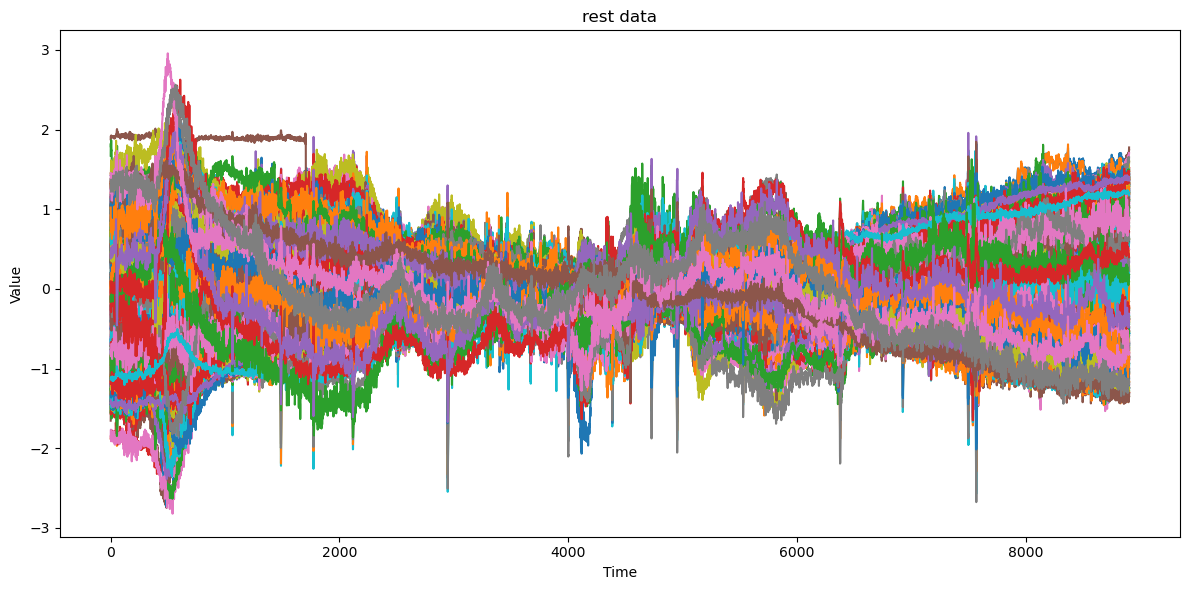

In [8]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(rest_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("rest data")
plt.tight_layout()
plt.show()

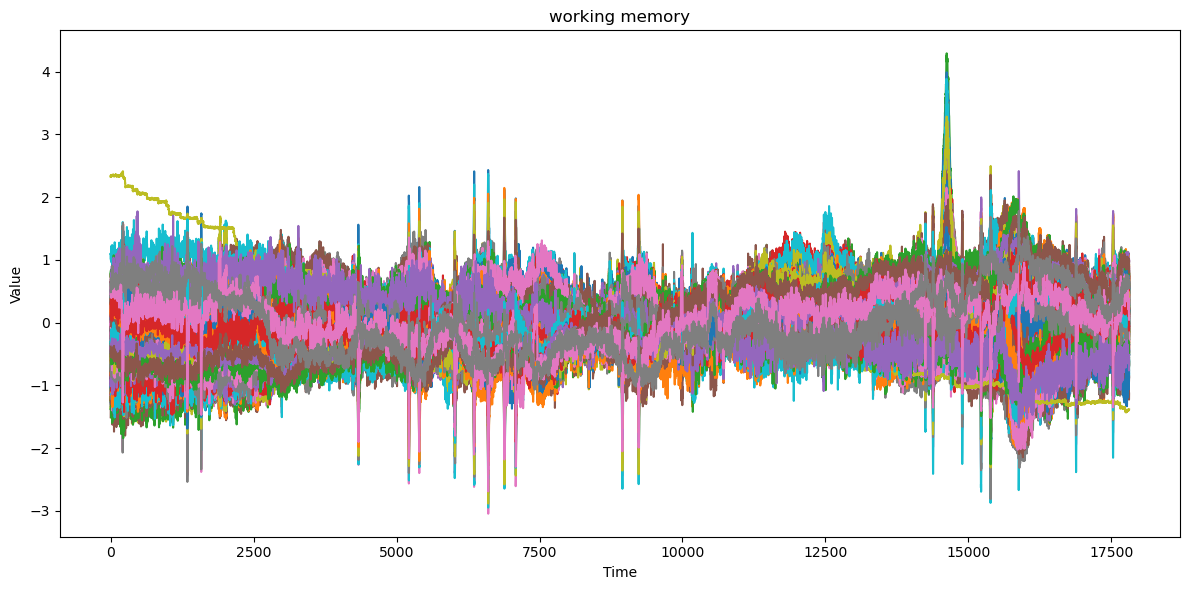

In [24]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(wm_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("working memory")
plt.tight_layout()
plt.show()

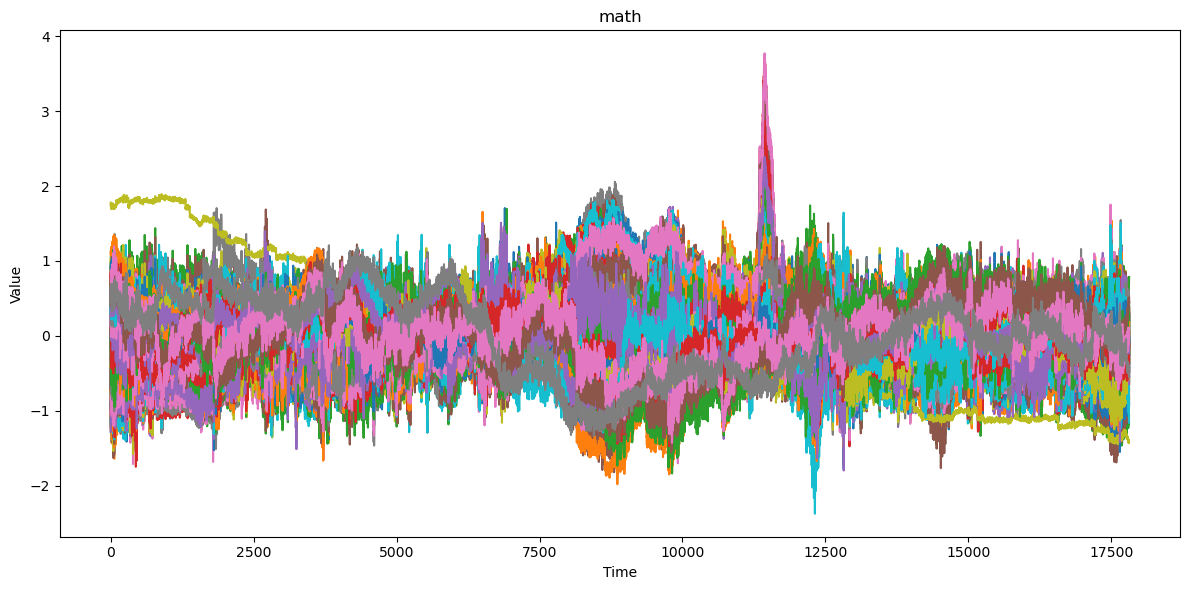

In [21]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(story_math_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("math")
plt.tight_layout()
plt.show()

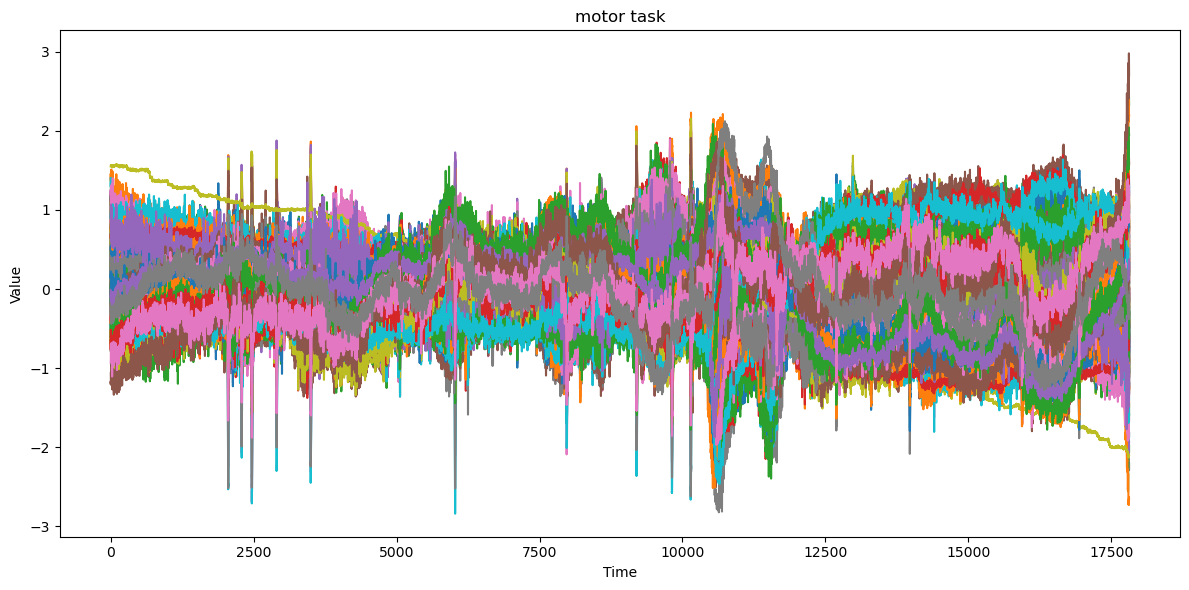

In [25]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(motor_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("motor task")
plt.tight_layout()
plt.show()

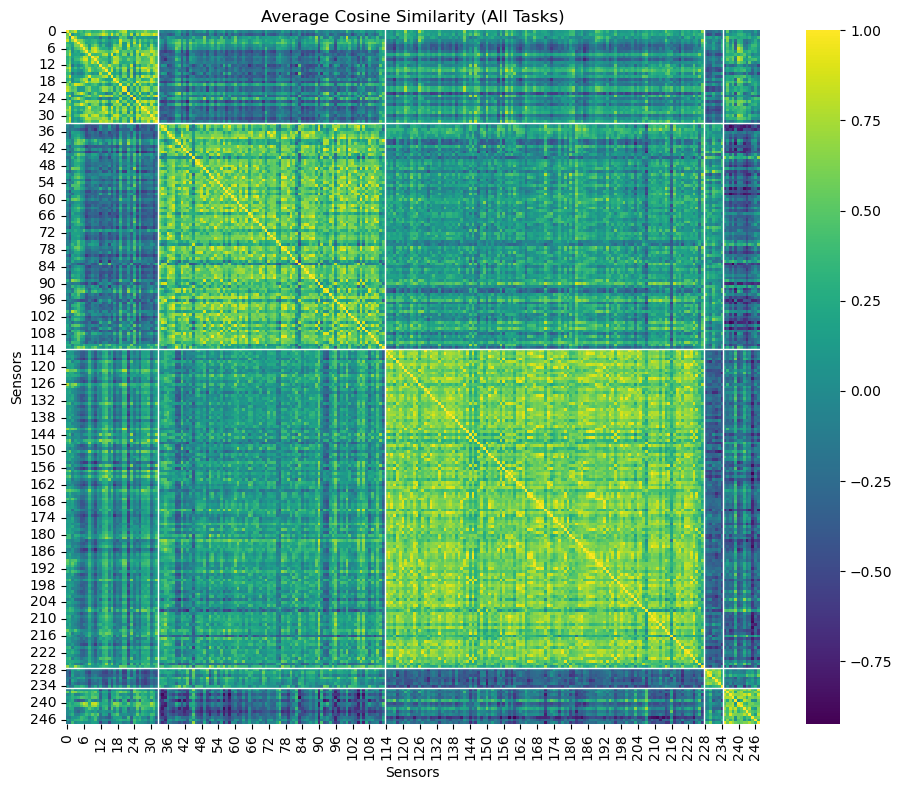

In [9]:
plot_avg_sensor_similarity(
    sim_matrix=avg_sim_matrix,
    sensor_order=sensor_order,
    cluster_labels=cluster_labels,
    title="Average Cosine Similarity (All Tasks)"
)

### Simple FFN

In [10]:
# Prepare data
X_train_ffnn = prepare_ffnn_data(X_train)
X_val_ffnn = prepare_ffnn_data(X_val)
X_all_ffnn = prepare_ffnn_data(X_all)

# Build FFNN model
def build_ffnn(input_shape, dense_units=128, dropout_rate=0.3, num_classes=4):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(dense_units // 2, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Instantiate and compile
ffnn_model = build_ffnn(input_shape=(X_train_ffnn.shape[1],))
ffnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
ffnn_model.fit(
    X_train_ffnn, y_train,
    validation_data=(X_val_ffnn, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

NameError: name 'X_train' is not defined

## Create training/validation sets for models


### No subchunk prediction

In [11]:
time_per_snapshot = 32       # 1s per snapshot isince it's sampled at 128 Hz
sequence_length = 6          # 10 snapshots per sequence (10s)
label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

# create input sequences
X_rest = make_sequences(rest_data, time_per_snapshot, sequence_length)
X_motor = make_sequences(motor_data, time_per_snapshot, sequence_length)
X_story = make_sequences(story_math_data, time_per_snapshot, sequence_length)
X_wm = make_sequences(wm_data, time_per_snapshot, sequence_length)

# output labels
y_rest = np.full((X_rest.shape[0],), label_map["rest"])
y_motor = np.full((X_motor.shape[0],), label_map["motor"])
y_story = np.full((X_story.shape[0],), label_map["story_math"])
y_wm = np.full((X_wm.shape[0],), label_map["wm"])

In [13]:
# combining all task data
X_all = np.concatenate([X_rest, X_motor, X_story, X_wm], axis=0)
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm], axis=0)

# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

### Subchunk prediction

In [14]:
time_per_snapshot = 32       # 1s per snapshot isince it's sampled at 128 Hz
sequence_length = 6          # 10 snapshots per sequence (10s)
label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

# Prepare inputs
data_list = [rest_data, motor_data, story_math_data, wm_data]
labels_list = [label_map["rest"], label_map["motor"], label_map["story_math"], label_map["wm"]]

# Generate sequences
X_all, y_all, ids_all = make_sequences_with_ids(
    data_list=data_list,
    labels_list=labels_list,
    time_per_snapshot=32,
    sequence_length=6
)

# train/val split
X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
    X_all, y_all, ids_all, test_size=0.2, random_state=42, stratify=y_all
)

In [15]:
from collections import Counter

def aggregate_predictions(predictions, ids):
    """
    Aggregate predictions using majority vote per group ID.
    
    Args:
        predictions: np.array of predicted class indices
        ids: sequence group IDs for each prediction
    
    Returns:
        Dict of {sequence_id: final_prediction}
    """
    final_preds = {}
    for seq_id in np.unique(ids):
        seq_preds = predictions[ids == seq_id]
        majority = Counter(seq_preds).most_common(1)[0][0]
        final_preds[seq_id] = majority
    return final_preds


### build/train single model

In [16]:
# CNN branch to encode a snapshot (spatial sensor pattern)
def build_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)  # shape: (sensors, time_per_snapshot)
    x = layers.Conv1D(32, kernel_size=5, activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)  # Output shape: (64,)
    model = models.Model(inputs, x, name='cnn_encoder')
    return model

# Combine CNN into RNN for full sequence classification
def build_cnn_rnn(cnn_encoder, snapshot_shape, sequence_length, num_classes=4):
    """
    snapshot_shape: tuple like (sensors, time_per_snapshot)
    sequence_length: number of snapshots per sequence
    """
    inputs = layers.Input(shape=(sequence_length,) + snapshot_shape)  # shape: (seq_len, sensors, time_per_snapshot)
    
    # Apply CNN to each snapshot in the sequence
    encoded = layers.TimeDistributed(cnn_encoder)(inputs)  # shape: (batch, seq_len, features)
    
    # Temporal modeling
    x = layers.GRU(128, return_sequences=False)(encoded)  # shape: (batch, 128)
    x = layers.Dense(64, activation='relu')(x)
    
    # Multiclass output
    output = layers.Dense(num_classes, activation='softmax')(x)  # shape: (batch, 4)
    
    model = models.Model(inputs, output, name='cnn_rnn_model')
    return model


In [19]:

cnn_encoder = build_cnn(input_shape=(X_all.shape[2], X_all.shape[3]))  # (sensors, time_per_snapshot)
model = build_cnn_rnn(cnn_encoder, snapshot_shape=(X_all.shape[2], X_all.shape[3]), sequence_length=sequence_length, num_classes=4)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train
intra_history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=16)


Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2490 - loss: 1.3811 - val_accuracy: 0.3962 - val_loss: 1.3374
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4538 - loss: 1.2950 - val_accuracy: 0.4151 - val_loss: 1.2269
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4803 - loss: 1.1131 - val_accuracy: 0.5472 - val_loss: 1.1639
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5717 - loss: 1.0069 - val_accuracy: 0.5472 - val_loss: 1.0384
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6139 - loss: 0.8968 - val_accuracy: 0.5283 - val_loss: 1.0956
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6810 - loss: 0.7973 - val_accuracy: 0.6226 - val_loss: 1.0135
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5734 - loss: 0.9357 - val_accuracy: 0.6226 - val_loss: 1.0017
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6202 - loss: 0.8731 - val_accuracy: 0.5849 - val_loss

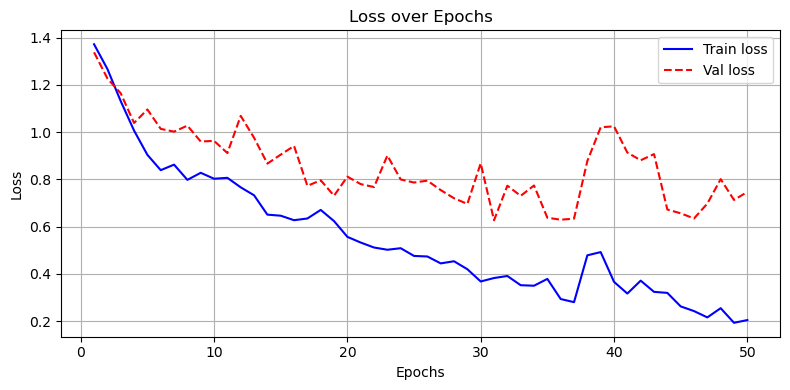

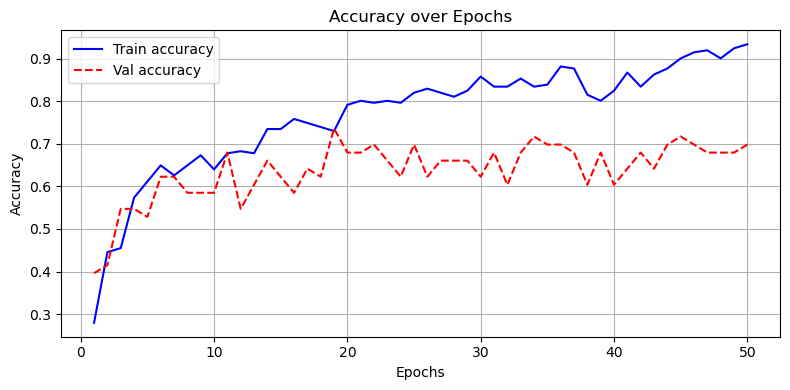

In [20]:
plot_training_history(intra_history, metrics=['loss', 'accuracy'])


## Grid hyperparameter search

In [32]:
from collections import defaultdict, Counter

# gridserach params
cnn_filters = [16, 32, 64]
kernel_sizes = [3, 5]
gru_units = [32, 64, 96, 128]
dense_sizes = [64, 128]
dropout_rates = [0.2, 0.3, 0.4]
learning_rates = [1e-3, 5e-4, 1e-4]
bidirectional_opts = [True, False]
batch_sizes = [8, 16]
epochs = [40, 50]


param_grid = list(itertools.product(
    cnn_filters, kernel_sizes, gru_units, dense_sizes,
    dropout_rates, learning_rates, bidirectional_opts,
    batch_sizes, epochs
))

n_trials = 30
random.seed(42)
sampled_configs = random.sample(param_grid, n_trials)

results = []

# function for majority vote calculation
def majority_vote(preds, ids):
    grouped = defaultdict(list)
    for p, i in zip(preds, ids):
        grouped[i].append(p)
    return {i: Counter(grouped[i]).most_common(1)[0][0] for i in grouped}

# train loop
for cnn_f, ksize, gru_u, dense_s, drop_r, lr, bi, batch_s, epoch_n in sampled_configs:
    print(f"\nTesting config: CNN={cnn_f}, KSize={ksize}, GRU={gru_u}, Dense={dense_s}, Dropout={drop_r}, LR={lr}, BiGRU={bi}, Batch={batch_s}, Epochs={epoch_n}")

    def build_cnn(input_shape):
        inputs = layers.Input(shape=input_shape)
        x = layers.Conv1D(cnn_f, kernel_size=ksize, activation='relu')(inputs)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Conv1D(cnn_f * 2, kernel_size=3, activation='relu')(x)
        x = layers.GlobalAveragePooling1D()(x)
        return models.Model(inputs, x)

    def build_model(snapshot_shape, sequence_length, num_classes=4):
        cnn_encoder = build_cnn(snapshot_shape)
        inputs = layers.Input(shape=(sequence_length,) + snapshot_shape)
        x = layers.TimeDistributed(cnn_encoder)(inputs)
        if bi:
            x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=True))(x)
            x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=True))(x)
            x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=False))(x)
        else:
            x = layers.GRU(gru_u, return_sequences=True)(x)
            x = layers.GRU(gru_u, return_sequences=True)(x)
            x = layers.GRU(gru_u, return_sequences=False)(x)
        x = layers.Dropout(drop_r)(x)
        x = layers.Dense(dense_s, activation='relu')(x)
        x = layers.Dropout(drop_r)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        return models.Model(inputs, outputs)

    model = build_model(snapshot_shape=(X_all.shape[2], X_all.shape[3]), sequence_length=sequence_length)
    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epoch_n, batch_size=batch_s, verbose=0)
    history_data = history.history

    # subchunk-level accuracy
    best_val_acc = max(history_data['val_accuracy'])
    best_val_loss = min(history_data['val_loss'])

    # subchunk-level predictions
    subchunk_preds = np.argmax(model.predict(X_val, batch_size=batch_s), axis=1)

    # aggregated sequence-level predictions
    aggregated_preds = majority_vote(subchunk_preds, ids_val)
    true_labels = {i: y_val[np.where(ids_val == i)[0][0]] for i in aggregated_preds}
    aggregated_acc = np.mean([aggregated_preds[i] == true_labels[i] for i in aggregated_preds])

    results.append({
        'val_accuracy': best_val_acc,
        'val_loss': best_val_loss,
        'agg_accuracy': aggregated_acc,
        'params': {
            'cnn_filters': cnn_f, 'kernel_size': ksize, 'gru_units': gru_u,
            'dense_size': dense_s, 'dropout': drop_r, 'learning_rate': lr,
            'bidirectional': bi, 'batch_size': batch_s, 'epochs': epoch_n
        },
        'history': history_data
    })

# --- Sort by both accuracy and loss ---
results.sort(key=lambda x: (-x['agg_accuracy'], x['val_loss']))

# --- Top 5 ---
print("\nTop 5 Configurations (by aggregated accuracy and loss):")
for r in results[:5]:
    print(f"Subchunk Val Acc: {r['val_accuracy']:.4f}, Seq Acc: {r['agg_accuracy']:.4f}, Val Loss: {r['val_loss']:.4f}, Params: {r['params']}")



Testing config: CNN=64, KSize=3, GRU=96, Dense=64, Dropout=0.3, LR=0.001, BiGRU=True, Batch=16, Epochs=50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step

Testing config: CNN=16, KSize=3, GRU=128, Dense=64, Dropout=0.3, LR=0.001, BiGRU=True, Batch=8, Epochs=40
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 285ms/step

Testing config: CNN=16, KSize=3, GRU=32, Dense=128, Dropout=0.3, LR=0.001, BiGRU=False, Batch=16, Epochs=40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step

Testing config: CNN=64, KSize=5, GRU=64, Dense=64, Dropout=0.2, LR=0.0005, BiGRU=False, Batch=8, Epochs=50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step

Testing config: CNN=16, KSize=5, GRU=128, Dense=128, Dropout=0.3, LR=0.0001, BiGRU=False, Batch=16, Epochs=40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 622ms/step

Testing config: CNN=16, KSize=5, GRU=96, Dense=128, Dropout=0.4, LR=0.0001, BiGRU=True, Batch=16, Epochs=50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 537ms/step

Testing config: CNN=16, KSize=5, GRU=96, Dense=64, Dropout=0.4, LR=0.001, BiGRU=True, Batch=16, Epochs=40
4/4 ━━━━━━━

Best Configuration:
  cnn_filters: 32
  kernel_size: 5
  gru_units: 128
  dense_size: 128
  dropout: 0.2
  learning_rate: 0.001
  bidirectional: True
  batch_size: 8
  epochs: 40


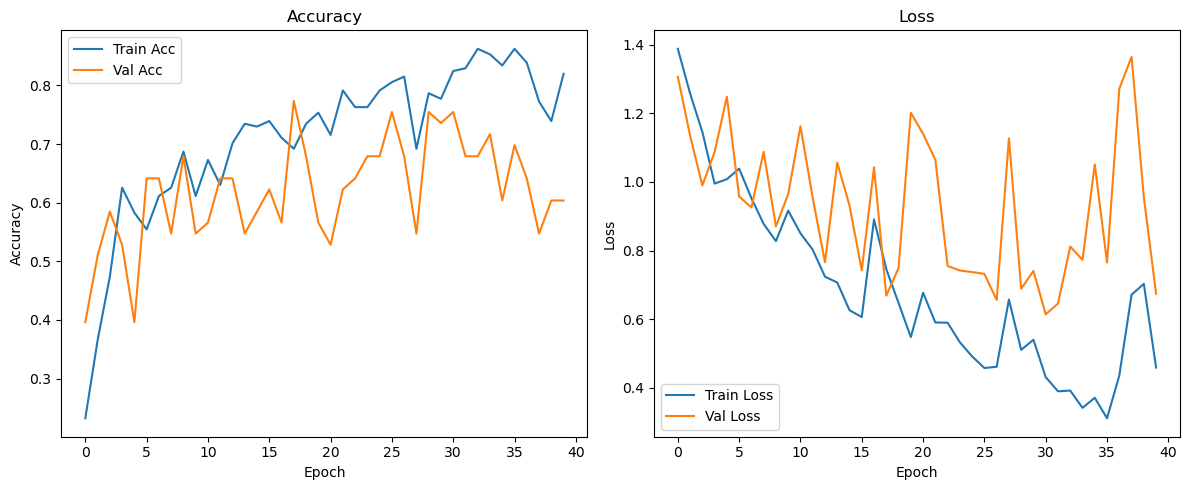

In [34]:
# Sort by best validation accuracy
results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Get the best result
best_result = results[0]
best_history = best_result['history']

# Print best config
print("Best Configuration:")
for k, v in best_result['params'].items():
    print(f"  {k}: {v}")

# Plotting training and validation accuracy/loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(best_history['accuracy'], label='Train Acc')
plt.plot(best_history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_history['loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Testing

## Intra Testing

## Contra Testing